In [1]:
import matplotlib.pyplot as plt
from mnist import load_mnist
from layers import *
from multi_layer_net import MultiLayerNet

In [2]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

In [3]:
train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000

In [4]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr
        
    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key] 

In [5]:
class Momentum:
    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)
        
        for key in params.keys():
            self.v[key] = self.momentum * self.v[key] - self.lr * grads[key]
            params[key] += self.v[key]

In [6]:
class AdaGrad:
    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)
        for key in params.keys():
            self.h[key] += grads[key] * grads[key]
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)

In [7]:
class Adam:

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.iter = 0
        self.m = None
        self.v = None
        
    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = {}, {}
            for key, val in params.items():
                self.m[key] = np.zeros_like(val)
                self.v[key] = np.zeros_like(val)
        
        self.iter += 1
        lr_t  = self.lr * np.sqrt(1.0 - self.beta2**self.iter) / (1.0 - self.beta1**self.iter)         
        
        for key in params.keys():
            self.m[key] += (1 - self.beta1) * (grads[key] - self.m[key])
            self.v[key] += (1 - self.beta2) * (grads[key]**2 - self.v[key])
            
            params[key] -= lr_t * self.m[key] / (np.sqrt(self.v[key]) + 1e-7)

In [8]:
optimizers = {}
optimizers['SGD'] = SGD()
optimizers['Momentum'] = Momentum()
optimizers['AdaGrad'] = AdaGrad()
optimizers['Adam'] = Adam()

In [9]:
networks = {}
train_loss = {}
for key in optimizers.keys():
    networks[key] = MultiLayerNet(
        input_size=784, hidden_size_list=[100, 100, 100, 100],
        output_size=10)
    train_loss[key] = []    

In [10]:
import time
times = {}
times['SGD'] = 0
times['Momentum'] = 0
times['AdaGrad'] = 0
times['Adam'] = 0

In [11]:
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in optimizers.keys():
        tic = time.time()
        grads = networks[key].gradient(x_batch, t_batch)
        optimizers[key].update(networks[key].params, grads)
        toc = time.time()
        times[key] += toc - tic
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print( "===========" + "iteration:" + str(i) + "===========")
        for key in optimizers.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


===========iteration:0===========
SGD:2.3364321664838883
Momentum:2.3705795603471724
AdaGrad:2.3932195030714496
Adam:2.241567988438554
===========iteration:100===========
SGD:1.6547324834224852
Momentum:0.31935085558259885
AdaGrad:0.127242621639338
Adam:0.23682388181271297
===========iteration:200===========
SGD:0.944581081028356
Momentum:0.26045036218853246
AdaGrad:0.12705282046359465
Adam:0.19757460909086455
===========iteration:300===========
SGD:0.48729838037230744
Momentum:0.09637401767737339
AdaGrad:0.04179596981208074
Adam:0.07374405498726695
===========iteration:400===========
SGD:0.4270922068004586
Momentum:0.150278337416033
AdaGrad:0.03691665809995545
Adam:0.04864991276215958
===========iteration:500===========
SGD:0.4272279680178628
Momentum:0.16934688302337275
AdaGrad:0.07362921788647664
Adam:0.12792753717953245
===========iteration:600===========
SGD:0.422560023140866
Momentum:0.20305339163781966
AdaGrad:0.09594023553217738
Adam:0.1852251976327876
===========iteration:700=

In [14]:
times

{'SGD': 2.0457210540771484,
 'Momentum': 2.180171012878418,
 'AdaGrad': 2.3291852474212646,
 'Adam': 2.520475149154663}

In [12]:
def smooth_curve(x):
    window_len = 11
    s = np.r_[x[window_len-1:0:-1], x, x[-1:-window_len:-1]]
    w = np.kaiser(window_len, 2)
    y = np.convolve(w/w.sum(), s, mode='valid')
    return y[5:len(y)-5]

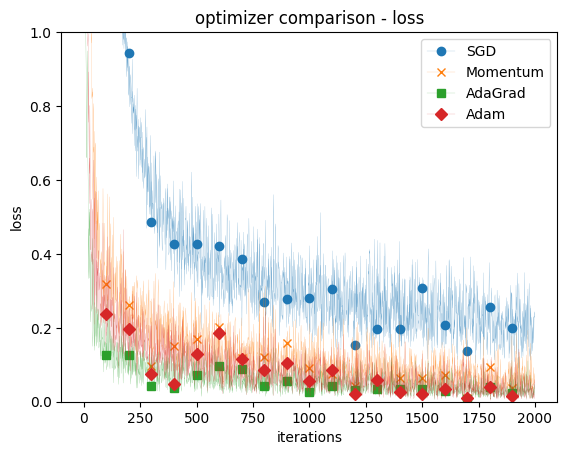

In [13]:
markers = {"SGD": "o", "Momentum": "x", "AdaGrad": "s", "Adam": "D"}
x = np.arange(max_iterations)
for key in optimizers.keys():
    plt.plot(x, train_loss[key], marker=markers[key], markevery=100, label=key, lw=0.1)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 1)
plt.legend()
plt.title("optimizer comparison - loss")
plt.show()